# Jet Image Reconstruction using Convolutional Autoencoder
Overview

This notebook implements Task-1 of the ML4SCI GSoC test, which focuses on learning compact representations of jet images using a convolutional autoencoder.

The objective is to train a neural network that can reconstruct jet images from compressed latent representations. The reconstruction error can later be used for tasks such as anomaly detection in particle physics data.

In [2]:
import h5py
import numpy as np
import sys, importlib
import torch
from torch.utils.data import TensorDataset, DataLoader
file_path = r"C:\quark_gluon_dataset.hdf5"

h5_file = h5py.File(file_path, "r")
X = h5_file["X_jets"][:8000]
y = h5_file["y"][:8000]

X = np.transpose(X, (0, 3, 1, 2))
X = X[:, :, :120, :120]

# Log normalization
X = np.log1p(X)
mean = X.mean()
std = X.std()
X = (X - mean) / std
print(f"After normalization: mean={X.mean():.4f}, std={X.std():.4f}")

# Convert to torch tensors
X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(y, dtype=torch.long)

# Create DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
train_loader = DataLoader(dataset, batch_size=64, shuffle=True)
print(f"Batches per epoch: {len(train_loader)}")

After normalization: mean=-0.0000, std=1.0000
Batches per epoch: 125


# Improved Jet Autoencoder

Drop-in replacement for the old `Autoencoder` class in `01_data_and_autoencoder.ipynb`.

## Key improvements

| Old | New |
|-----|-----|
| 3-stage encoder (32→64→64) | 4-stage encoder (32→64→128→256) |
| `BatchNorm` | `GroupNorm(8)` — batch-size independent |
| `ReLU` | `LeakyReLU(0.2)` — no dead neurons |
| `Upsample + Conv` | `ConvTranspose2d` — learned, no artefacts |
| No residual blocks | Residual blocks in every stage |
| Latent ≈ 230 K dims | Latent ≈ 12.5 K dims (19× smaller) |
| `Adam` | `AdamW` + `OneCycleLR` + gradient clipping |

---
**Run notebook `01_data_and_autoencoder.ipynb` first** so that `X_tensor`, `y_tensor`,
and `train_loader` are already available in your kernel — OR re-run the data
preparation cells below.



# 0  ·  Data preparation  (re-run if needed)
## Dataset Description

The dataset consists of jet images stored in an HDF5 file. Each jet is represented as a 3-channel image corresponding to detector measurements:

ECAL (Electromagnetic Calorimeter)

HCAL (Hadronic Calorimeter)

Track information

Each sample has the shape:

(3, 120, 120)

Where:

The first dimension represents detector channels

The spatial dimensions correspond to energy deposition in the detector grid

Skip to **Section 1** if `train_loader` is already in your kernel from notebook 01.

## 1  ·  Import the improved model


In [3]:
import sys, importlib
sys.path.insert(0, "/kaggle/input/models/harshsharma040207/jet-autoencoder/other/default/1")  # folder containing jet_autoencoder.py

import jet_autoencoder as jae
importlib.reload(jae)

<module 'jet_autoencoder' from 'C:\\ml4sci_gsoc_test\\jet_autoencoder.py'>

In [4]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# 2  ·  Inspect the architecture
## Model Architecture
A Convolutional Autoencoder is used, consisting of:
## Encoder
Multiple convolutional layers
Downsampling via stride or pooling
Extraction of compact latent representation
## Decoder
Upsampling layers
Convolutional layers to reconstruct the input image
Output matches original input dimensions
The model learns to compress and reconstruct jet images while preserving important spatial and energy patterns.
Training Set

In [5]:
model = jae.JetAutoencoder(latent_channels=256, dropout=0.1)
print(model)

# Count trainable parameters
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {n_params:,}")

# Quick forward-pass shape check
dummy = torch.zeros(2, 3, 120, 120)
with torch.no_grad():
    out = model(dummy)
print(f"Input shape : {dummy.shape}")
print(f"Output shape: {out.shape}")

JetAutoencoder(
  (enc1): DownBlock(
    (conv): Sequential(
      (0): Conv2d(3, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 32, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0.2, inplace=True)
    )
    (res): ResBlock(
      (block): Sequential(
        (0): GroupNorm(8, 32, eps=1e-05, affine=True)
        (1): LeakyReLU(negative_slope=0.2, inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (3): GroupNorm(8, 32, eps=1e-05, affine=True)
        (4): LeakyReLU(negative_slope=0.2, inplace=True)
        (5): Dropout2d(p=0.1, inplace=False)
        (6): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      )
    )
  )
  (enc2): DownBlock(
    (conv): Sequential(
      (0): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
      (1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (2): LeakyReLU(negative_slope=0

## 3  ·  Training with AdamW + OneCycleLR

**Expected loss curve**

| Epoch range | Approximate MSE |
|-------------|----------------|
| 1 – 10      | 0.80 → 0.15    |
| 10 – 40     | 0.15 → 0.05    |
| 40 – 80     | 0.05 → 0.025   |
| 80+         | plateau        |

In [6]:
EPOCHS = 100

model = jae.JetAutoencoder(latent_channels=256, dropout=0.1)
optimizer, scheduler = jae.make_optimizer(
    model, train_loader,
    epochs=EPOCHS,
    base_lr=3e-4,
    max_lr=1e-3,
    weight_decay=1e-4,
)

loss_history = jae.train(
    model, train_loader, optimizer, scheduler,
    epochs=EPOCHS,
    device=device,
    grad_clip=1.0,
    print_every=5,     # print every 5 epochs
)

Epoch    5 | Loss: 0.536145
Epoch   10 | Loss: 0.425308
Epoch   15 | Loss: 0.334847
Epoch   20 | Loss: 0.293462
Epoch   25 | Loss: 0.261372
Epoch   30 | Loss: 0.243098
Epoch   35 | Loss: 0.225965
Epoch   40 | Loss: 0.210249
Epoch   45 | Loss: 0.199091
Epoch   50 | Loss: 0.190668
Epoch   55 | Loss: 0.181358
Epoch   60 | Loss: 0.175932
Epoch   65 | Loss: 0.168835
Epoch   70 | Loss: 0.163661
Epoch   75 | Loss: 0.158440
Epoch   80 | Loss: 0.155349
Epoch   85 | Loss: 0.152037
Epoch   90 | Loss: 0.150222
Epoch   95 | Loss: 0.149839
Epoch  100 | Loss: 0.150078


## 4  ·  Plot the loss curve

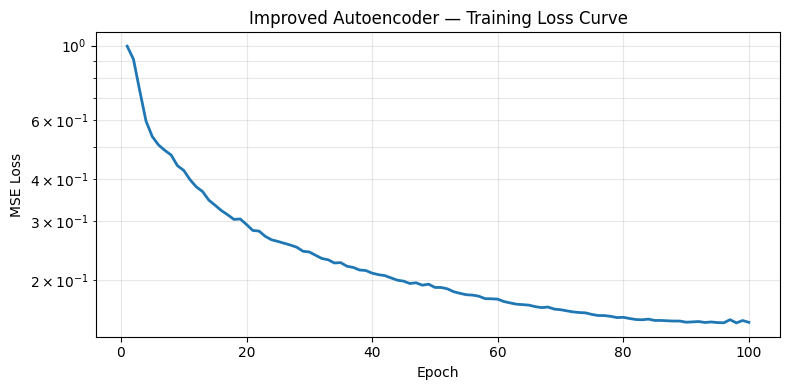

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(loss_history) + 1), loss_history, linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Improved Autoencoder — Training Loss Curve")
plt.yscale("log")   # log-scale shows the fine tail
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 5  ·  Visualise reconstructions

Compare original vs reconstructed ECAL images.

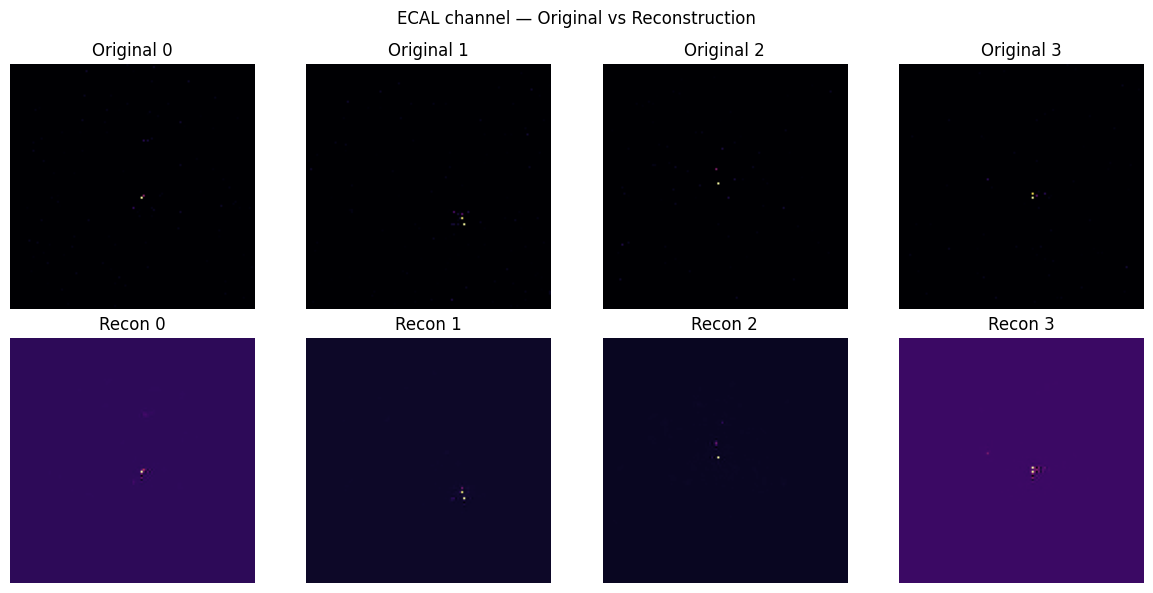

In [8]:
jae.visualise_reconstructions(model, train_loader, device=device, n=4)

## 6  ·  Reconstruction error as anomaly score

Compute per-sample MSE and plot the histogram.  
In an anomaly-detection scenario you would overlay **signal** jets here —
they should have a **higher** reconstruction error than background QCD jets.


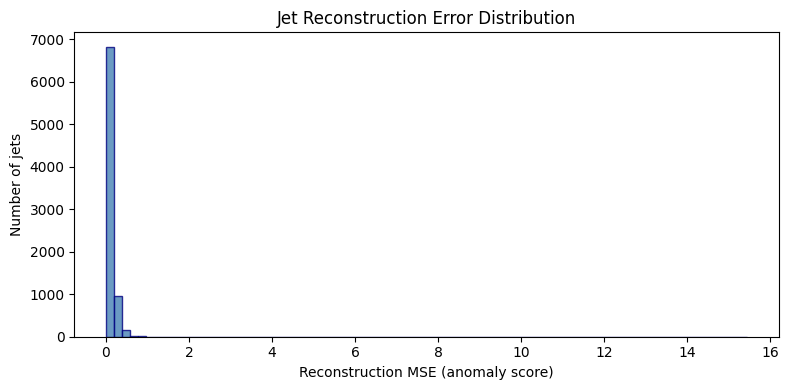

Mean score : 0.13957
Std  score : 0.28106
Max  score : 15.43539


In [9]:
model.eval()
all_scores = []

with torch.no_grad():
    for batch in train_loader:
        images = batch[0].to(device)
        scores = model.anomaly_score(images)
        all_scores.extend(scores.cpu().numpy())

plt.figure(figsize=(8, 4))
plt.hist(all_scores, bins=80, color="steelblue", edgecolor="navy", alpha=0.8)
plt.xlabel("Reconstruction MSE (anomaly score)")
plt.ylabel("Number of jets")
plt.title("Jet Reconstruction Error Distribution")
plt.tight_layout()
plt.show()

print(f"Mean score : {np.mean(all_scores):.5f}")
print(f"Std  score : {np.std(all_scores):.5f}")
print(f"Max  score : {np.max(all_scores):.5f}")

## 7  ·  Training-stability debugging checks

Run this cell right after the **first epoch** to confirm nothing is broken.

In [10]:
sample_batch = next(iter(train_loader))[0]
print(f"Input  mean: {sample_batch.mean().item():.4f}  "
      f"std: {sample_batch.std().item():.4f}")

model.train()
loss = torch.nn.functional.mse_loss(model(sample_batch.to(device)),
                                     sample_batch.to(device))
loss.backward()

total_norm = 0.0
for p in model.parameters():
    if p.grad is not None:
        total_norm += p.grad.data.norm(2).item() ** 2
total_norm = total_norm ** 0.5
print(f"Gradient norm: {total_norm:.4f}  (healthy range: 0.01 – 10.0)")


model.eval()
with torch.no_grad():
    recon = model(sample_batch.to(device))
print(f"Recon pixel std: {recon.std().item():.4f}")


assert not torch.isnan(recon).any(), "NaN in reconstruction!"
assert not torch.isinf(recon).any(), "Inf in reconstruction!"
print("No NaN / Inf detected. ✓")

Input  mean: 0.0029  std: 1.1225
Gradient norm: 0.1740  (healthy range: 0.01 – 10.0)
Recon pixel std: 1.0457
No NaN / Inf detected. ✓
